# TRABAJO ACADÉMICO INTELIGENCIA ARTIFICIAL 2025-2

## Diccionario de datos

**Descripción de las variables**
* Location - Nombre de la ciudad de Australia
* MinTemp - La temperatura mínima durante un día particular. (grados Celsius)
* MaxTemp - La temperatura máxima durante un día particular. (grados Celsius)
* Rainfall - Precipitación durante un día particular. (milímetros)
* Evaporation - Evaporación durante un día particular. (milímetros)
* Sunshine - Sol brillante durante un día particular. (horas)
* WindGusDir - Dirección de la ráfaga más fuerte durante un día particular. (16 puntos cardinales)
* WindGuSpeed - Velocidad de la ráfaga más fuerte durante un día particular. (Km/h)
* WindDir9am - Dirección del viento durante los 10 minutos anteriores a las 9 am. (puntos cardinales)
* WindDir3pm - Dirección del viento durante los 10 minutos anteriores a las 3 pm. (puntos cardinales)
* WindSpeed9am - Velocidad del viento durante los 10 minutos anteriores a las 9 am. (Km/h)
* WindSpeed3pm - Velocidad del viento durante los 10 minutos anteriores a las 3 pm. (Km/h)
* Humidity9am - Humedad del viento a las 9 am. (porcentaje)
* Humidity3pm - Humedad del viento a las 3 pm. (porcentaje)
* Pressure9am - Presión atmosférica a las 9 am. (hectopascales)
* Pressure3pm - Presión atmosférica a las 3 pm. (hectopascales)
* Cloud9am - Porciones del cielo oscurecidas por nubes a las 9 am. (octavos)
* Cloud3pm - Porciones del cielo oscurecidas por nubes a las 3 pm. (octavos)
* Temp9am - Temperatura a las 9 am. (grados Celsius)
* Temp3pm - Temperatura a las 3 pm. (grados Celsius)
* RainToday - Si hoy llueve, entonces ‘Yes’. Si no llueve, entonces ‘No’.
* **RainTomorrow** - Si mañana llueve entonces 1 (Yes). Si mañana no llueve entonces 0 (No). Variable target.


## Librerías

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, regularizers

In [ ]:
df = pd.read_csv("AustraliaWeatherDataset.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99516 entries, 0 to 99515
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         99516 non-null  object 
 1   Location       99516 non-null  object 
 2   MinTemp        99073 non-null  float64
 3   MaxTemp        99286 non-null  float64
 4   Rainfall       98537 non-null  float64
 5   Evaporation    56985 non-null  float64
 6   Sunshine       52199 non-null  float64
 7   WindGustDir    92995 non-null  object 
 8   WindGustSpeed  93036 non-null  float64
 9   WindDir9am     92510 non-null  object 
 10  WindDir3pm     96868 non-null  object 
 11  WindSpeed9am   98581 non-null  float64
 12  WindSpeed3pm   97681 non-null  float64
 13  Humidity9am    98283 non-null  float64
 14  Humidity3pm    97010 non-null  float64
 15  Pressure9am    89768 non-null  float64
 16  Pressure3pm    89780 non-null  float64
 17  Cloud9am       61944 non-null  float64
 18  Cloud3

In [ ]:
df.head()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Row0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0
1,Row1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0
2,Row2,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0
3,Row3,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,0
4,Row4,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,0


In [ ]:
# No es útil
df = df.drop(columns=['row ID'])

In [ ]:
# Porcentaje de nulos ordenados de mayor a menor entre todas las columnas
porcentaje_nulos = (df.isnull().sum() / len(df)).sort_values(ascending=False) * 100
print("Porcentajes de valores nulos por columna")
print(porcentaje_nulos)

Porcentajes de valores nulos por columna
Sunshine         47.547128
Evaporation      42.737851
Cloud3pm         40.196551
Cloud9am         37.754733
Pressure9am       9.795410
Pressure3pm       9.783351
WindDir9am        7.040074
WindGustDir       6.552715
WindGustSpeed     6.511516
WindDir3pm        2.660879
Humidity3pm       2.518188
Temp3pm           1.913260
WindSpeed3pm      1.843925
Humidity9am       1.238997
RainToday         0.983761
Rainfall          0.983761
WindSpeed9am      0.939547
Temp9am           0.616986
MinTemp           0.445155
MaxTemp           0.231119
Location          0.000000
RainTomorrow      0.000000
dtype: float64


In [ ]:
numeric_cols=df.select_dtypes('number')
numeric_cols.columns.tolist()

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainTomorrow']

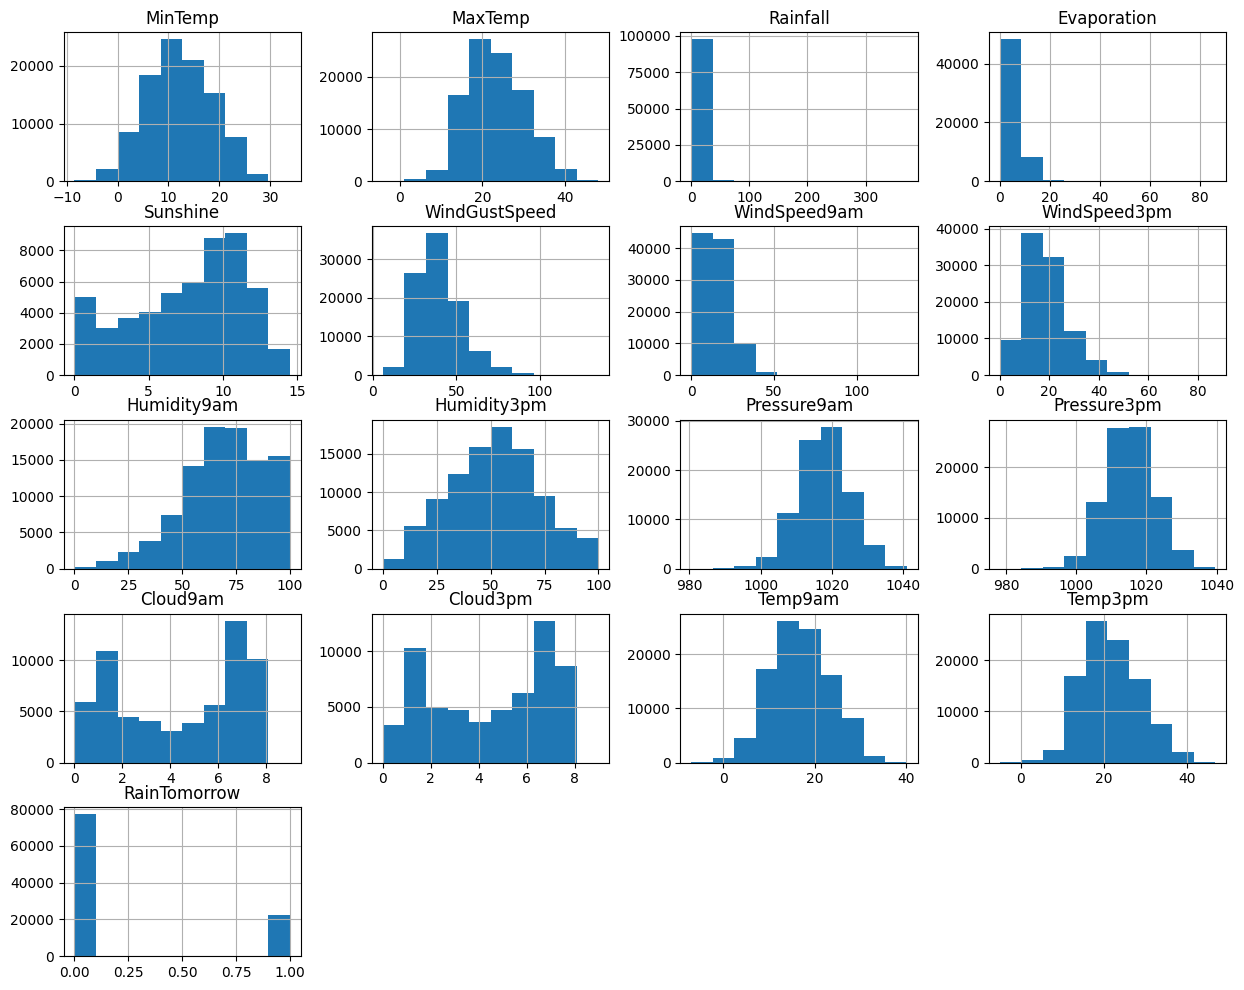

In [ ]:
df.hist(figsize=[15,12])
plt.show()

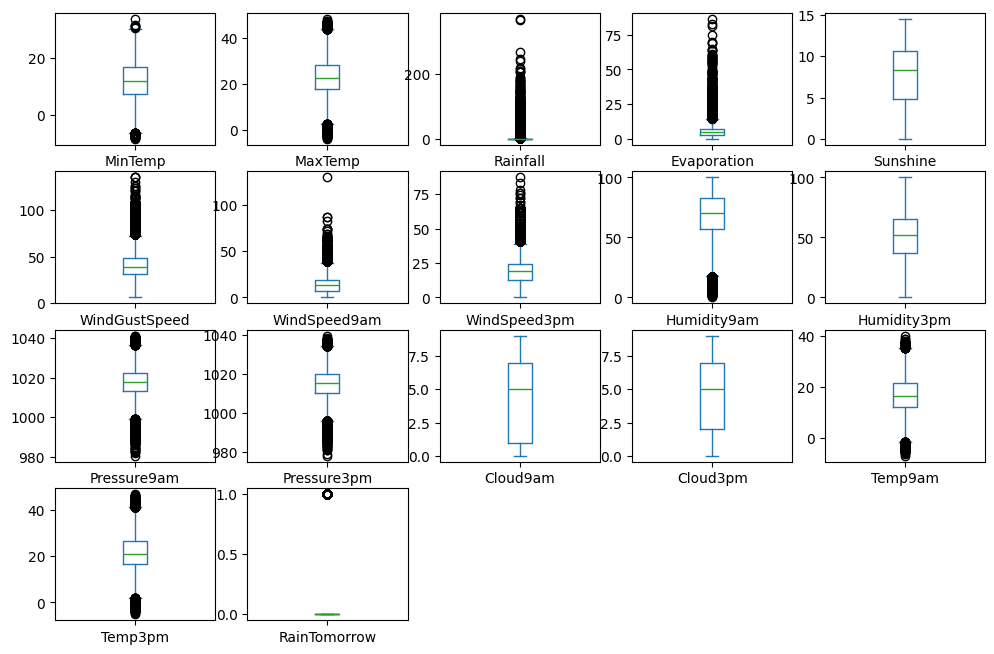

In [ ]:
df.plot(kind='box', subplots=True, layout=(6,5), sharex=True, sharey=False,  figsize=[12,12])
plt.show()

In [ ]:
# Función para identificar outliers
def es_outlier(df, columna, umbral=1.5):
  q1 = df[columna].quantile(0.25)
  q3 = df[columna].quantile(0.75)
  iqr = q3 - q1
  return (df[columna]<q1-umbral*iqr)|(df[columna]>q3+umbral*iqr)

In [ ]:
# Manejo de outliers solo en las variables predictoras que lo requieran
variables_outliers=['MinTemp','MaxTemp','Rainfall','Evaporation','WindGustSpeed',
                    'WindSpeed9am','WindSpeed3pm','Humidity9am','Pressure9am','Pressure3pm',
                    'Temp9am','Temp3pm']
for variable in variables_outliers:
  indices_outliers = df.loc[es_outlier(df,variable)].index
  df.drop(index=indices_outliers, inplace=True)

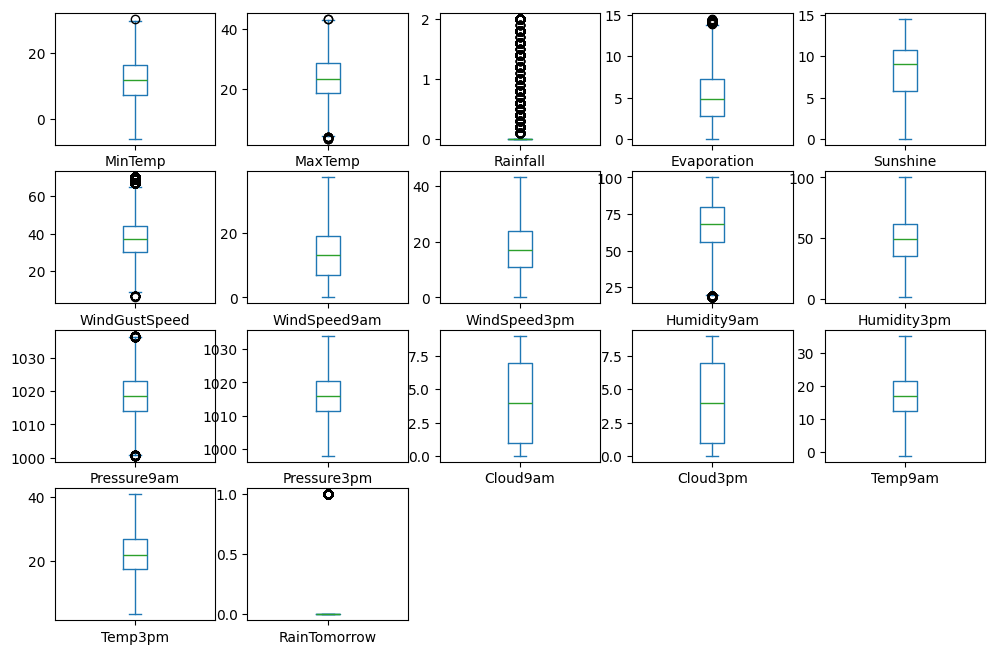

In [ ]:
df.plot(kind='box', subplots=True, layout=(6,5), sharex=True, sharey=False,  figsize=[12,12])
plt.show()

In [ ]:
df.Pressure9am.describe()

,Pressure9am
count,68865.000000
mean,1018.720076
std,6.455160
min,1000.500000
25%,1014.200000
50%,1018.600000
75%,1023.100000
max,1036.800000


# Imputación de nulos

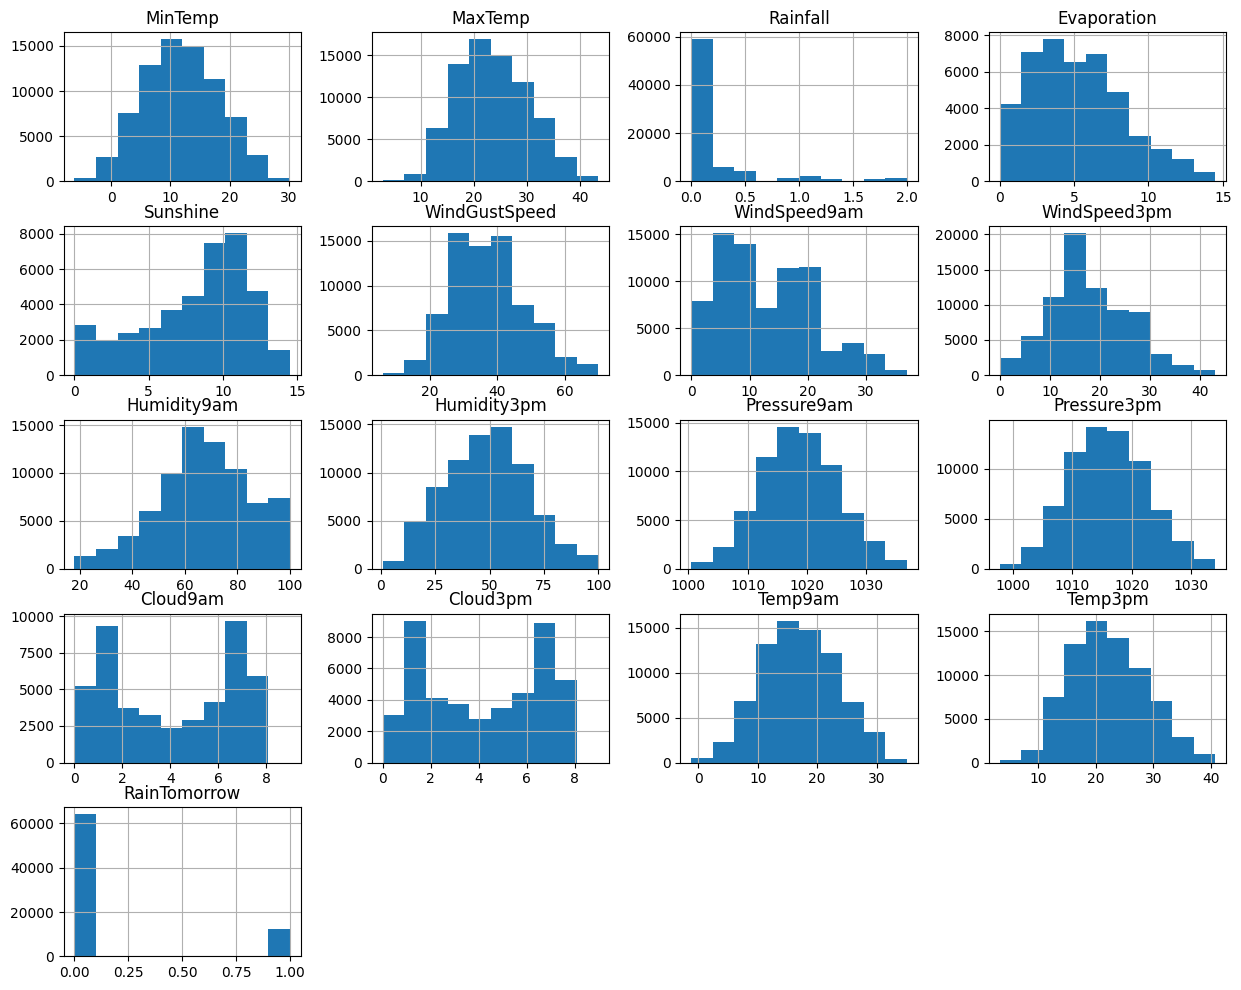

In [ ]:
df.hist(figsize=[15,12])
plt.show()

In [ ]:
# Porcentaje de nulos ordenados de mayor a menor entre todas las columnas
porcentaje_nulos = (df.isnull().sum() / len(df)).sort_values(ascending=False) * 100
print("Porcentajes de valores nulos por columna")
print(porcentaje_nulos)

Porcentajes de valores nulos por columna
Sunshine         48.096048
Evaporation      43.272703
Cloud3pm         41.443339
Cloud9am         38.958388
Pressure9am       9.886155
Pressure3pm       9.854750
WindDir9am        7.698247
WindGustDir       6.503533
WindGustSpeed     6.469511
WindDir3pm        2.651138
Humidity3pm       2.456163
Temp3pm           1.863387
WindSpeed3pm      1.829364
Humidity9am       1.184245
RainToday         1.164617
Rainfall          1.164617
WindSpeed9am      0.982727
Temp9am           0.583617
MinTemp           0.476315
MaxTemp           0.242083
Location          0.000000
RainTomorrow      0.000000
dtype: float64


In [ ]:
# Imputamos con la media en variables predictoras numéricas que siguen distribución normal
normal_cols = ['MinTemp','MaxTemp','WindGustSpeed','WindSpeed3pm','Humidity3pm','Pressure9am',
               'Pressure3pm','Temp9am','Temp3pm']

for col in normal_cols:
  df[col]=df[col].fillna(df[col].mean())

In [ ]:
# Imputamos con la mediana en variables predictoras numéricas que no siguen distribución normal
not_normal_cols = ['Rainfall','Evaporation','Sunshine','WindSpeed9am','Humidity9am','Cloud9am','Cloud3pm']
for col in not_normal_cols:
  df[col]=df[col].fillna(df[col].median())

In [ ]:
# Porcentaje de nulos ordenados de mayor a menor entre todas las columnas
porcentaje_nulos = (df.isnull().sum() / len(df)).sort_values(ascending=False) * 100
print("Porcentajes de valores nulos por columna")
print(porcentaje_nulos)

Porcentajes de valores nulos por columna
WindDir9am       7.698247
WindGustDir      6.503533
WindDir3pm       2.651138
RainToday        1.164617
Location         0.000000
MinTemp          0.000000
Sunshine         0.000000
Evaporation      0.000000
Rainfall         0.000000
MaxTemp          0.000000
WindSpeed9am     0.000000
WindSpeed3pm     0.000000
Humidity9am      0.000000
WindGustSpeed    0.000000
Humidity3pm      0.000000
Pressure9am      0.000000
Cloud9am         0.000000
Pressure3pm      0.000000
Cloud3pm         0.000000
Temp9am          0.000000
Temp3pm          0.000000
RainTomorrow     0.000000
dtype: float64


In [ ]:
categoric_cols=df.select_dtypes('object').columns.to_list()
categoric_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

In [ ]:
df.describe(include='object')

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
count,76420,71450,70537,74394,75530
unique,49,16,16,16,2
top,Canberra,E,N,SE,No
freq,1960,5278,5924,5833,71497


In [ ]:
# Imputamos con la moda en variables predictoras categóricas donde aún se tengan nulos
for col in categoric_cols:
  if(col!='Location'):
    df[col]=df[col].fillna(df[col].mode()[0])

In [ ]:
df.describe(include='object')

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
count,76420,76420,76420,76420,76420
unique,49,16,16,16,2
top,Canberra,E,N,SE,No
freq,1960,10248,11807,7859,72387


In [ ]:
# Porcentaje de nulos ordenados de mayor a menor entre todas las columnas
porcentaje_nulos = (df.isnull().sum() / len(df)).sort_values(ascending=False) * 100
print("Porcentajes de valores nulos por columna")
print(porcentaje_nulos)

Porcentajes de valores nulos por columna
Location         0.0
MinTemp          0.0
MaxTemp          0.0
Rainfall         0.0
Evaporation      0.0
Sunshine         0.0
WindGustDir      0.0
WindGustSpeed    0.0
WindDir9am       0.0
WindDir3pm       0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am      0.0
Humidity3pm      0.0
Pressure9am      0.0
Pressure3pm      0.0
Cloud9am         0.0
Cloud3pm         0.0
Temp9am          0.0
Temp3pm          0.0
RainToday        0.0
RainTomorrow     0.0
dtype: float64


In [ ]:
for col in categoric_cols:
  print(f'Columna {col}')
  print(f'Valores únicos: {df[col].unique()}')
  print(f'Hay {df[col].nunique()} valores unicos en {col}\n')

Columna Location
Valores únicos: ['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']
Hay 49 valores unicos en Location

Columna WindGustDir
Valores únicos: ['W' 'WNW' 'N' 'ENE' 'SSE' 'NE' 'WSW' 'SW' 'NNW' 'S' 'E' 'NW' 'SSW' 'ESE'
 'NNE' 'SE']
Hay 16 valores unicos en WindGustDir

Columna WindDir9am
Valores únicos: ['W' 'NNW' 'ENE' 'SSE' 'S' 'N' 'SSW' 'SE' 'NE' 'ESE' 'E' 'NW' 'WSW' 'NNE'
 'SW' 'WNW']
Hay 16 valores unicos en WindDir9am

Columna WindDir3pm
Valores únic

In [ ]:
df['RainToday'].value_counts()

,count
RainToday,
No,72387
Yes,4033


In [ ]:
df['RainTomorrow'].value_counts()

,count
RainTomorrow,
0,64116
1,12304


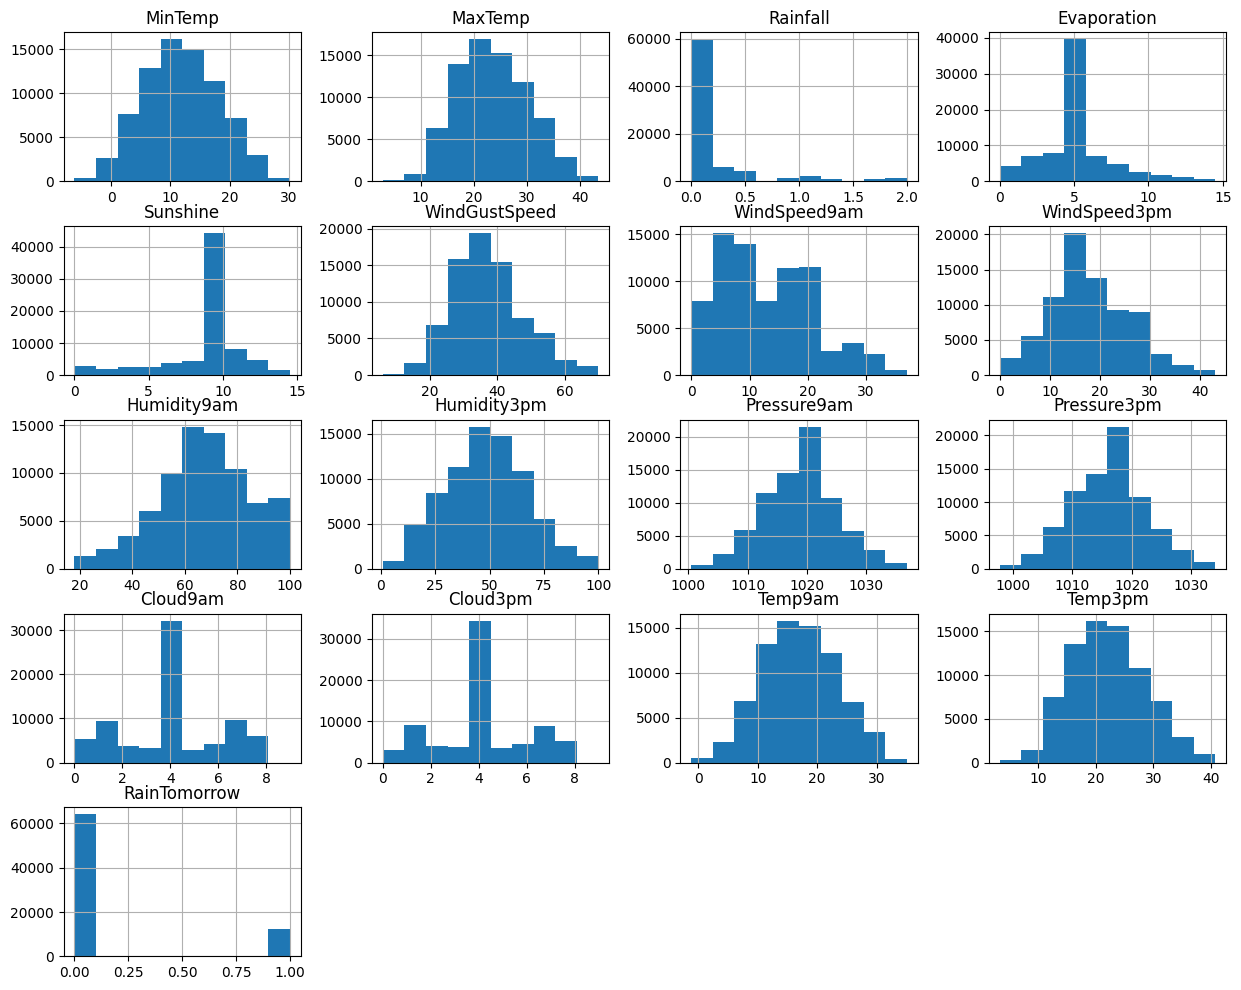

In [ ]:
df.hist(figsize=[15,12])
plt.show()

In [ ]:
# Ninguna de las variables categóricas tiene relación de orden, se usará One-Hot-Encoding
df = pd.get_dummies(df, columns=categoric_cols, drop_first=True, prefix=categoric_cols)

print("\\nColumnas después del encoding:")
print(df.columns.tolist())

\nColumnas después del encoding:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainTomorrow', 'Location_Albany', 'Location_Albury', 'Location_AliceSprings', 'Location_BadgerysCreek', 'Location_Ballarat', 'Location_Bendigo', 'Location_Brisbane', 'Location_Cairns', 'Location_Canberra', 'Location_Cobar', 'Location_CoffsHarbour', 'Location_Dartmoor', 'Location_Darwin', 'Location_GoldCoast', 'Location_Hobart', 'Location_Katherine', 'Location_Launceston', 'Location_Melbourne', 'Location_MelbourneAirport', 'Location_Mildura', 'Location_Moree', 'Location_MountGambier', 'Location_MountGinini', 'Location_Newcastle', 'Location_Nhil', 'Location_NorahHead', 'Location_NorfolkIsland', 'Location_Nuriootpa', 'Location_PearceRAAF', 'Location_Penrith', 'Location_Perth', 'Location_PerthAirport', 'Location_Portland', 'Location_Richmond',

In [ ]:
df.shape

(76420, 111)

In [ ]:
df.dtypes

,0
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
...,...
WindDir3pm_SW,bool
WindDir3pm_W,bool
WindDir3pm_WNW,bool
WindDir3pm_WSW,bool


In [ ]:
numeric_cols=df.select_dtypes('number')
numeric_cols.columns.tolist()

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainTomorrow']

Realizamos matriz de correlación solo para las variables numéricas

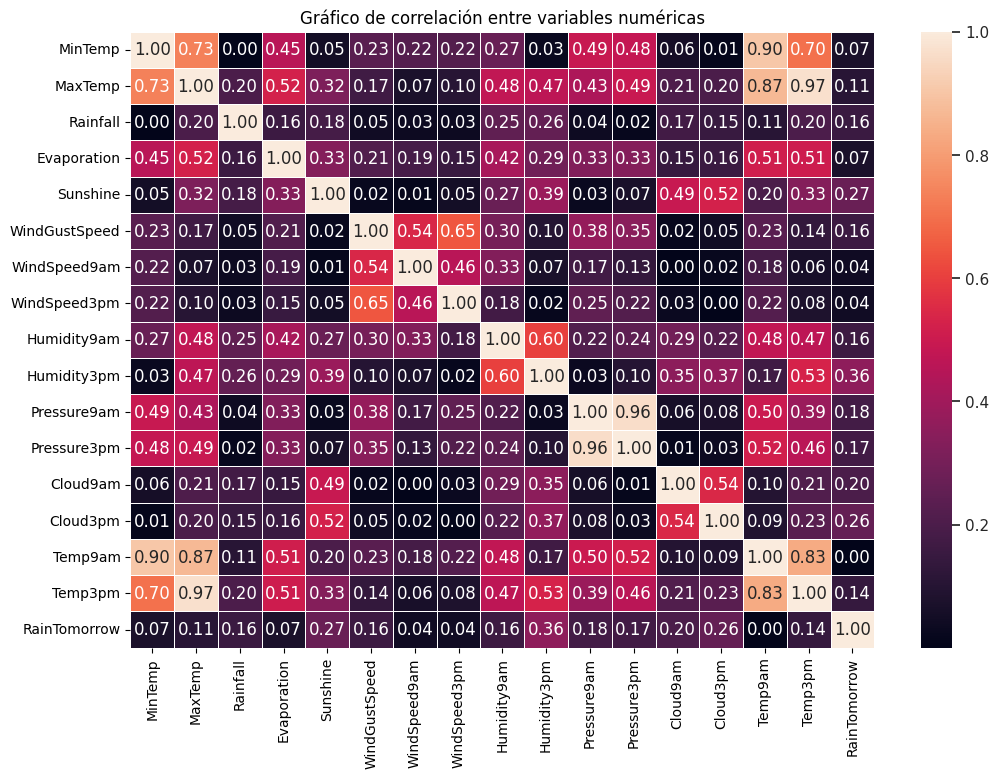

In [ ]:
f, ax =plt.subplots(figsize=(12, 8))
sns.set()
plt.title('Gráfico de correlación entre variables numéricas')
sns.heatmap(abs(numeric_cols.corr()), annot=True, linewidth=.5, fmt='.2f', ax=ax)
plt.show()

In [ ]:
# Se eliminará la primera variable de cada par donde haya correlaciones fuertes (>=0.9)
df = df.drop(columns=['Temp9am','Temp3pm','Pressure3pm'])
df.shape

(76420, 108)

# Entrenamiento del modelo

In [ ]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

No hay balance claro

In [ ]:
y.value_counts()

,count
RainTomorrow,
0,64116
1,12304


In [ ]:
# Usamos stratify para manejar desbalanceo y asegurarnos que se divida en las mismas proporciones
# 20% datos para el test y 80% para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
numeric_predic=X.select_dtypes('number').columns.to_list()
numeric_predic

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Cloud9am',
 'Cloud3pm']

In [ ]:
# Estandarizar variables numéricas
scaler = MinMaxScaler(feature_range=(-1,1))

X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()

# Entrenamiento: aprender + transformar
X_train_minmax[numeric_predic] = scaler.fit_transform(X_train_minmax[numeric_predic])
# Test: transformar usando parámetros ya aprendidos
X_test_minmax[numeric_predic] = scaler.transform(X_test_minmax[numeric_predic])

In [ ]:
y_train.value_counts()

,count
RainTomorrow,
0,51293
1,9843


In [ ]:
y_test.value_counts()

,count
RainTomorrow,
0,12823
1,2461


In [ ]:
# Misma relación en base al target
print(51293/(51293+9843))
print(12823/(12823+2461))

0.8389982988746402
0.8389819419000262


In [ ]:
# opcional para convertir True a 1 y False a 0 en columnas booleanas
bool_cols = X_train_minmax.select_dtypes(include="bool").columns
X_train_minmax[bool_cols] = X_train_minmax[bool_cols].astype(int)

In [ ]:
X_train_minmax

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_Yes
48219,-0.376045,-0.358025,-1.0,-0.613793,-0.806897,-0.156250,-0.405405,-0.395349,0.609756,0.151515,...,0,0,0,0,0,0,0,0,1,0
17473,0.214485,0.283951,-1.0,-0.337931,0.255172,-0.375000,-0.783784,-0.674419,-0.073171,-0.232323,...,0,0,0,0,0,0,0,0,0,0
68618,-0.387187,-0.664198,-1.0,-0.806897,-1.000000,-0.031250,-0.081081,-0.209302,0.756098,0.939394,...,0,0,0,0,0,0,0,0,0,0
23877,-0.147632,-0.451852,-0.4,-0.724138,-1.000000,-0.012979,0.621622,-0.069767,0.414634,0.717172,...,0,0,0,1,0,0,0,0,0,0
80775,-0.442897,-0.150617,0.4,-0.613793,0.600000,-0.031250,0.081081,0.116279,-0.414634,-0.373737,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26252,-0.715877,-0.096296,-1.0,-0.144828,0.751724,-0.437500,-0.621622,-0.488372,-0.073171,-0.797980,...,0,0,0,0,0,0,1,0,0,0
91675,-0.392758,-0.427160,-1.0,-0.337931,0.255172,-0.500000,-1.000000,-0.720930,0.902439,0.191919,...,0,0,0,0,0,0,0,0,0,0
31444,-0.125348,-0.264198,-1.0,-0.531034,-0.089655,0.031250,-0.081081,-0.069767,0.073171,-0.050505,...,0,0,1,0,0,0,0,0,0,0
40083,-0.537604,-0.283951,-1.0,-0.862069,0.255172,-0.312500,-0.783784,-0.488372,0.414634,-0.171717,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout, BatchNormalization

In [ ]:
INPUTS = X_train_minmax.shape[1]

In [ ]:
# Hiperparámetros
n_epochs = 50
learning_rate = 0.001
batch_size = 32

In [ ]:
model = Sequential([
  # Capa inicial
  keras.layers.InputLayer(shape=(INPUTS,), batch_size=None),
  # Capas ocultas
  # como se usa función de activación relu, es recomendable usar inicialización HeNormal (ayuda a que converja más pronto)
  Dense(64,activation='relu',kernel_initializer=keras.initializers.HeNormal(seed=None),kernel_regularizer=regularizers.l2(1e-4)),
  BatchNormalization(),
  # Técnica de regularización Dropout (dropout rate 0.5, probabilidad que una neurona se quede 50%)
  Dropout(rate=0.5),
  # Dense(128,activation='relu',kernel_initializer=keras.initializers.HeNormal(seed=None)),
  # BatchNormalization(),
  # Dropout(rate=0.25),
  # Dense(128,activation='relu',kernel_initializer=keras.initializers.HeNormal(seed=None)),
  # BatchNormalization(),
  # Dropout(rate=0.25),
  Dense(32,activation='relu',kernel_initializer=keras.initializers.HeNormal(seed=None),kernel_regularizer=regularizers.l2(1e-4)),
  BatchNormalization(),
  Dropout(rate=0.25),
  Dense(16,activation='relu',kernel_initializer=keras.initializers.HeNormal(seed=None),kernel_regularizer=regularizers.l2(1e-4)),
  BatchNormalization(),
  Dropout(rate=0.25),
  Dense(8,activation='relu',kernel_initializer=keras.initializers.HeNormal(seed=None),kernel_regularizer=regularizers.l2(1e-4)),
  BatchNormalization(),
  Dropout(rate=0.25),
  # Capa de salida, como solo es una neurona, recomendable función de activación sigmoide
  Dense(1, activation='sigmoid')
])

In [ ]:
from tensorflow.keras.optimizers import Adam

Ventajas de binary_accuracy sobre accuracy:

- Evita errores de interpretación
- Mide la exactitud verdadera del clasificador binario
- Es más coherente con capas de salida sigmoid

In [ ]:
# Optimizador Adam (combina momentum y RMSprop)
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['binary_accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,145 (39.63 KB)

 Trainable params: 9,905 (38.69 KB)

 Non-trainable params: 240 (960.00 B)

Entrenamiento del modelo

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# Para saber cuánto tiempo duró el entrenamiento
import time
callbacks=[
  EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
  ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

start = time.perf_counter()
history = model.fit(
  x = X_train_minmax, # datos de entrada
  y = y_train, # etiquetas o salidas esperadas
  batch_size = batch_size, # número de muestras de entrenamiento
  epochs = n_epochs,
  validation_split = 0.2, # 20% para validación y 80% de entrenamiento
  verbose = 1, # ver progreso
  callbacks = callbacks
  # class_weight = {0:1, 1:1.5}
)

print ("Tiempo de entrenamiento:",time.perf_counter() - start, "s")

Epoch 1/50
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - binary_accuracy: 0.7314 - loss: 0.5935 - val_binary_accuracy: 0.8639 - val_loss: 0.3601 - learning_rate: 0.0010
Epoch 2/50
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - binary_accuracy: 0.8478 - loss: 0.3890 - val_binary_accuracy: 0.8677 - val_loss: 0.3440 - learning_rate: 0.0010
Epoch 3/50
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - binary_accuracy: 0.8512 - loss: 0.3744 - val_binary_accuracy: 0.8714 - val_loss: 0.3357 - learning_rate: 0.0010
Epoch 4/50
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - binary_accuracy: 0.8510 - loss: 0.3682 - val_binary_accuracy: 0.8690 - val_loss: 0.3327 - learning_rate: 0.0010
Epoch 5/50
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - binary_accuracy: 0.8561 - loss: 0.3578 - val_binary_accuracy: 0.8695 - val_loss: 0.3303 - learning_rate: 0.0010
Epoch 6/50
1529/1529 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - binary_accuracy: 0.8575 - loss: 0.3528 - val_binary_accuracy: 0.8723 - val_loss: 0.3244 - learning_rat

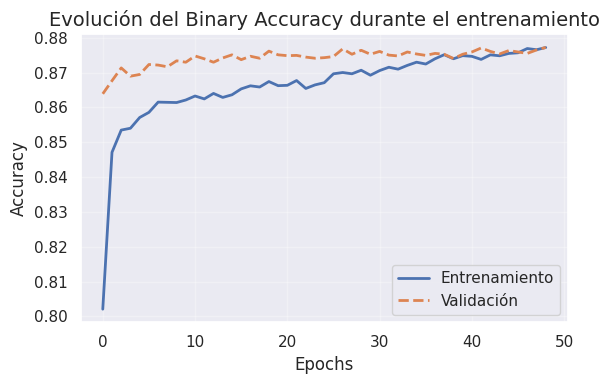

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['binary_accuracy'],
         label='Entrenamiento',
         linewidth=2)

plt.plot(history.history['val_binary_accuracy'],
         label='Validación',
         linewidth=2,
         linestyle='--')

plt.title('Evolución del Binary Accuracy durante el entrenamiento', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


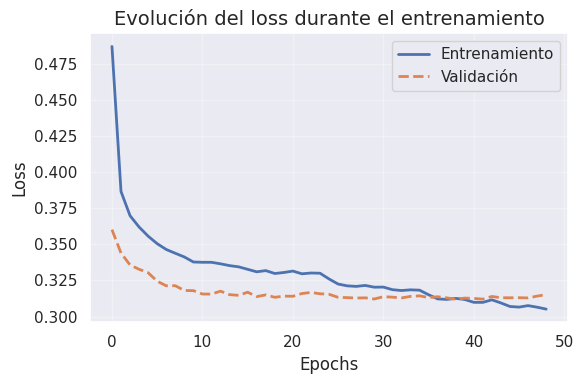

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'],
         label='Entrenamiento',
         linewidth=2)

plt.plot(history.history['val_loss'],
         label='Validación',
         linewidth=2,
         linestyle='--')

plt.title('Evolución del loss durante el entrenamiento', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
y_pred_prob = model.predict(X_test_minmax)

478/478 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


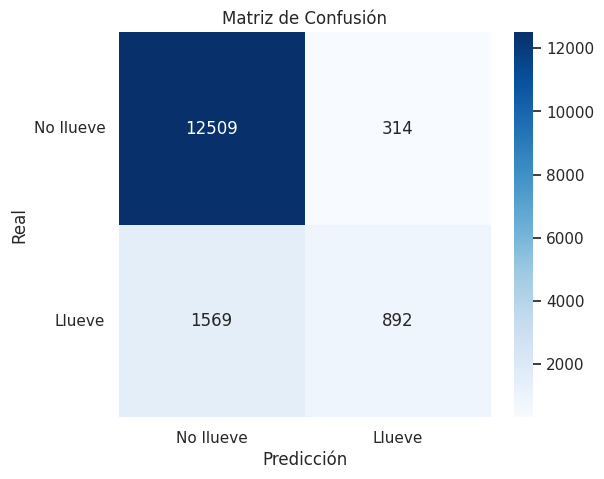

In [ ]:
y_pred_class = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0.5, 1.5], ["No llueve", "Llueve"])
plt.yticks([0.5, 1.5], ["No llueve", "Llueve"], rotation=0)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_pred_class,target_names=['No_Llueve','Llueve']))

              precision    recall  f1-score   support

   No_Llueve       0.89      0.98      0.93     12823
      Llueve       0.74      0.36      0.49      2461

    accuracy                           0.88     15284
   macro avg       0.81      0.67      0.71     15284
weighted avg       0.86      0.88      0.86     15284



Un modelo que detecta lluvia bastante bien (recall)

Pero que genera alertas falsas (precision)